# Flow-stretched DNA exploration notebook

This notebook uses `flow_stretched_dna_model.py` and `flow_stretched_dna_params.py` in the same folder.

It is organized around the four plots you asked for:

1. **Force vs extension** for DNA molecules of different lengths
2. **Flow rate vs extension**
3. **Flow rate vs force**
4. **Channel height vs shear rate**

## How to use

1. Keep this notebook in the same directory as `flow_stretched_dna_model.py` and `flow_stretched_dna_params.py`.
2. Edit the parameter cells below.
3. Re-run the cells for the plots you want to update.

The notebook reads the default physical parameters from `flow_stretched_dna_params.py`, but you can override them inside the notebook without changing the script.


In [20]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

HERE = Path.cwd()
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import flow_stretched_dna_model as model

PARAMS_PATH = HERE / 'flow_stretched_dna_params.py'
run_config = model.load_run_config(PARAMS_PATH)
base_params = run_config.params

print(f'Loaded defaults from: {PARAMS_PATH}')
print(f'Default DNA length: {run_config.dna_length_bp} bp')
print(f'Default channel height: {run_config.channel_height_um} um')
print(f'Default channel width: {run_config.channel_width_um} um')
print(f'Default flow rates: {run_config.flow_rates_ul_min}')


Loaded defaults from: /Users/saurabhtalele/Saurabh/WORK/Codes/fsdna_model_issac_li/flow_stretched_dna_params.py
Default DNA length: 22900 bp
Default channel height: 120.0 um
Default channel width: 1200.0 um
Default flow rates: [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]


In [21]:
dna_lengths_bp = [8000, 14000, 16000, 22900, 48502]

In [22]:
# Helper functions

def make_params(**overrides):
    data = dict(
        alpha=base_params.alpha,
        beta=base_params.beta,
        gamma=base_params.gamma,
        nominal_segment_bp=base_params.nominal_segment_bp,
        temperature_c=base_params.temperature_c,
        persistence_length_nm=base_params.persistence_length_nm,
        stretch_modulus_pN=base_params.stretch_modulus_pN,
        viscosity_pa_s=base_params.viscosity_pa_s,
    )
    data.update(overrides)
    return model.ModelParams(**data)


def shear_rate_s_inv(flow_rate_ul_min, channel_height_um, channel_width_um):
    q_m3_s = model.ul_min_to_m3_s(flow_rate_ul_min)
    h_m = model.um_to_m(channel_height_um)
    w_m = model.um_to_m(channel_width_um)
    return 6.0 * q_m3_s / (h_m * h_m * w_m)


def force_extension_curve(length_bp, forces_pN, params=None):
    if params is None:
        params = base_params
    contour_um = model.contour_length_um_from_bp(length_bp)
    extensions_um = [
        contour_um * model.extwlc_extension_fraction(
            force_pN=float(F),
            contour_um=contour_um,
            persistence_length_nm=params.persistence_length_nm,
            stretch_modulus_pN=params.stretch_modulus_pN,
            kbt_pN_nm=params.kbt_pN_nm,
        )
        for F in forces_pN
    ]
    return np.array(extensions_um)


def prediction_table(flow_rates_ul_min, dna_lengths_bp, channel_height_um=None, channel_width_um=None, params=None):
    if params is None:
        params = base_params
    if channel_height_um is None:
        channel_height_um = run_config.channel_height_um
    if channel_width_um is None:
        channel_width_um = run_config.channel_width_um

    rows = []
    for length_bp in dna_lengths_bp:
        for flow in flow_rates_ul_min:
            pred = model.predict_extension(
                flow_rate_ul_min=float(flow),
                channel_height_um=float(channel_height_um),
                channel_width_um=float(channel_width_um),
                dna_length_bp=int(length_bp),
                params=params,
            )
            rows.append({
                'dna_length_bp': int(length_bp),
                'flow_rate_ul_min': float(flow),
                'shear_stress_Pa': pred.shear_stress_pa,
                'shear_rate_s_inv': pred.shear_stress_pa / params.viscosity_pa_s,
                'anchor_force_pN': pred.anchor_force_pN,
                'extension_um': pred.extension_um,
                'contour_length_um': pred.contour_length_um,
                'fractional_extension': pred.fractional_extension,
            })
    return pd.DataFrame(rows)


## 1) Force vs extension for different DNA lengths

This is the **extWLC constitutive curve** for full DNA molecules of the chosen lengths.
The force law is the same model used segment-by-segment in the flow calculation, but here it is applied to the whole contour length so you can inspect the elastic response directly.


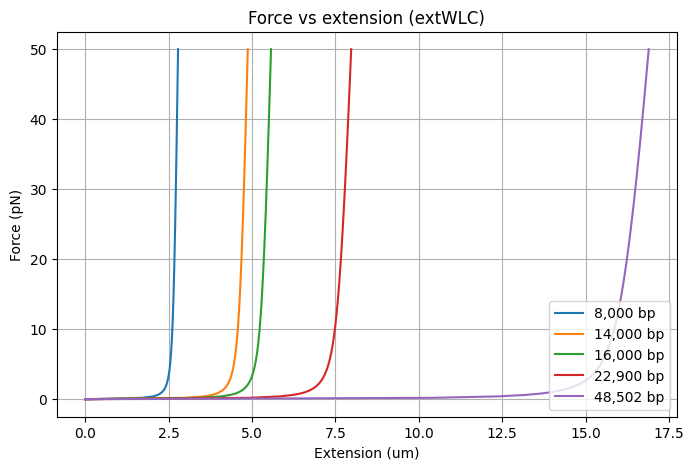

In [23]:
# Edit this cell, then re-run it.
lengths_for_force_extension_bp = dna_lengths_bp
force_min_pN = 0.0
force_max_pN = 50.0
n_force_points = 250

params_for_force_extension = make_params()
forces_pN = np.linspace(force_min_pN, force_max_pN, n_force_points)

plt.figure()
for length_bp in lengths_for_force_extension_bp:
    extension_um = force_extension_curve(length_bp, forces_pN, params=params_for_force_extension)
    plt.plot(extension_um, forces_pN, label=f'{length_bp:,} bp')

plt.xlabel('Extension (um)')
plt.ylabel('Force (pN)')
plt.title('Force vs extension (extWLC)')
plt.legend()
plt.show()


## 2) Flow rate vs extension

This uses the full hydrodynamic + segment-drag + extWLC model.
You can overlay several DNA lengths on the same axes.


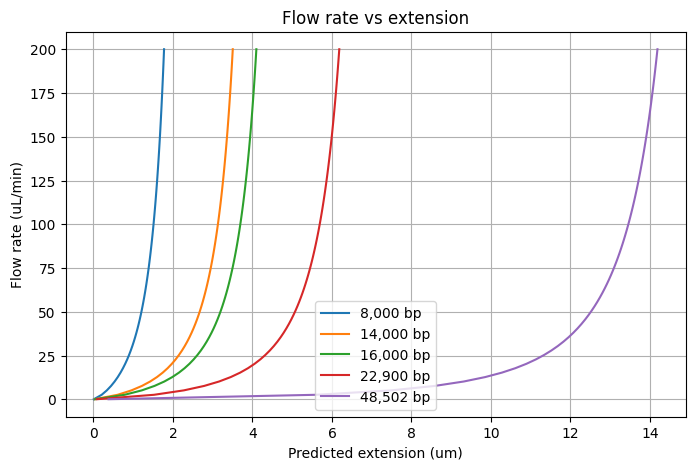

,dna_length_bp,flow_rate_ul_min,shear_stress_Pa,shear_rate_s_inv,anchor_force_pN,extension_um,contour_length_um,fractional_extension
0,8000,0.050000,0.000290,0.289352,0.000964,0.010452,2.72,0.003843
1,8000,2.581013,0.014966,14.936416,0.020178,0.207670,2.72,0.076349
2,8000,5.112025,0.029643,29.583480,0.034176,0.337739,2.72,0.124169
3,8000,7.643038,0.044319,44.230544,0.046600,0.443547,2.72,0.163069
4,8000,10.174051,0.058995,58.877608,0.058099,0.533641,2.72,0.196192


In [24]:
# Edit this cell, then re-run it.
lengths_for_flow_extension_bp = dna_lengths_bp
flow_min_ul_min = 0.05
flow_max_ul_min = 200.0
n_flow_points = 80
channel_height_um = run_config.channel_height_um
channel_width_um = run_config.channel_width_um

params_for_flow_extension = make_params()
flow_rates = np.linspace(flow_min_ul_min, flow_max_ul_min, n_flow_points)
df_flow_ext = prediction_table(
    flow_rates_ul_min=flow_rates,
    dna_lengths_bp=lengths_for_flow_extension_bp,
    channel_height_um=channel_height_um,
    channel_width_um=channel_width_um,
    params=params_for_flow_extension,
)

plt.figure()
for length_bp in lengths_for_flow_extension_bp:
    sub = df_flow_ext[df_flow_ext['dna_length_bp'] == length_bp]
    plt.plot( sub['extension_um'],sub['flow_rate_ul_min'], label=f'{length_bp:,} bp')

plt.xlabel('Predicted extension (um)')
plt.ylabel('Flow rate (uL/min)')
plt.title('Flow rate vs extension')
plt.legend()
plt.show()

df_flow_ext.head()


## 3) Flow rate vs force

This shows the **anchor force** predicted by the model as a function of flow rate.


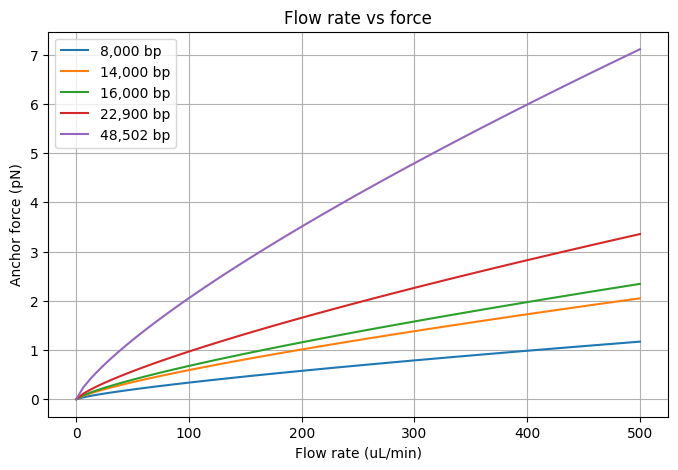

,dna_length_bp,flow_rate_ul_min,shear_stress_Pa,shear_rate_s_inv,anchor_force_pN,extension_um,contour_length_um,fractional_extension
0,8000,0.050000,0.000290,0.289352,0.000964,0.010452,2.72,0.003843
1,8000,6.378481,0.036986,36.912506,0.040535,0.393013,2.72,0.144490
2,8000,12.706962,0.073683,73.535660,0.068962,0.612199,2.72,0.225073
3,8000,19.035443,0.110379,110.158814,0.094175,0.772379,2.72,0.283963
4,8000,25.363924,0.147076,146.781968,0.117501,0.896958,2.72,0.329764


In [28]:
# Edit this cell, then re-run it.
lengths_for_flow_force_bp = dna_lengths_bp
flow_min_ul_min = 0.05
flow_max_ul_min = 500
n_flow_points = 80
channel_height_um = run_config.channel_height_um
channel_width_um = run_config.channel_width_um

params_for_flow_force = make_params()
flow_rates = np.linspace(flow_min_ul_min, flow_max_ul_min, n_flow_points)
df_flow_force = prediction_table(
    flow_rates_ul_min=flow_rates,
    dna_lengths_bp=lengths_for_flow_force_bp,
    channel_height_um=channel_height_um,
    channel_width_um=channel_width_um,
    params=params_for_flow_force,
)

plt.figure()
for length_bp in lengths_for_flow_force_bp:
    sub = df_flow_force[df_flow_force['dna_length_bp'] == length_bp]
    plt.plot(sub['flow_rate_ul_min'], sub['anchor_force_pN'], label=f'{length_bp:,} bp')

plt.xlabel('Flow rate (uL/min)')
plt.ylabel('Anchor force (pN)')
plt.title('Flow rate vs force')
plt.legend()
plt.show()

df_flow_force.head()


## 4) Channel height vs shear rate

For a rectangular channel in this model,

\[
\dot\gamma_w = 
rac{\sigma}{\eta} = 
rac{6Q}{h^2 w}
\]

so this plot is a pure flow-geometry relation and does not depend on the DNA mechanics.


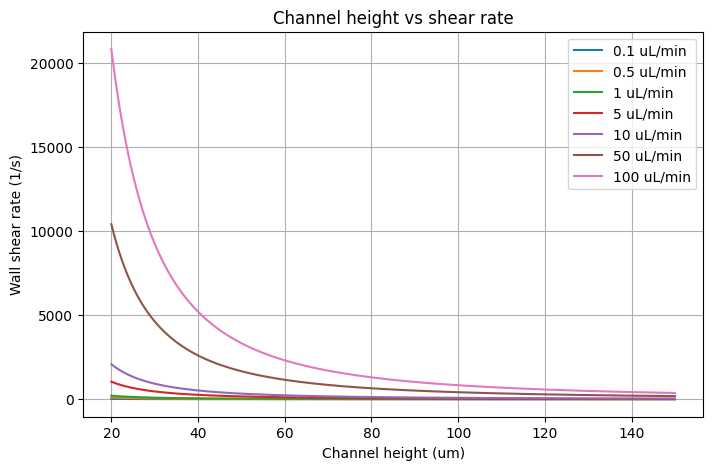

In [26]:
# Edit this cell, then re-run it.
flow_rates_for_height_plot_ul_min = np.array([0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0])
height_min_um = 20.0
height_max_um = 150.0
n_height_points = 200
channel_width_um = run_config.channel_width_um

heights_um = np.linspace(height_min_um, height_max_um, n_height_points)

plt.figure()
for flow in flow_rates_for_height_plot_ul_min:
    gamma_dot = [shear_rate_s_inv(flow, h, channel_width_um) for h in heights_um]
    plt.plot(heights_um, gamma_dot, label=f'{flow:g} uL/min')

plt.xlabel('Channel height (um)')
plt.ylabel('Wall shear rate (1/s)')
plt.title('Channel height vs shear rate')
plt.legend()
plt.show()


## Optional: compare parameter changes quickly

You can override any model parameter here without editing the main parameter file.
For example, change persistence length, viscosity, or stretch modulus and regenerate the plots.


In [27]:
# Example override block
custom_params = make_params(
    persistence_length_nm=base_params.persistence_length_nm,
    stretch_modulus_pN=base_params.stretch_modulus_pN,
    viscosity_pa_s=base_params.viscosity_pa_s,
)

summary_flows = run_config.flow_rates_ul_min
summary_lengths = [run_config.dna_length_bp]
summary_df = prediction_table(
    flow_rates_ul_min=summary_flows,
    dna_lengths_bp=summary_lengths,
    channel_height_um=run_config.channel_height_um,
    channel_width_um=run_config.channel_width_um,
    params=custom_params,
)
summary_df


,dna_length_bp,flow_rate_ul_min,shear_stress_Pa,shear_rate_s_inv,anchor_force_pN,extension_um,contour_length_um,fractional_extension
0,22900,0.1,0.000580,0.578704,0.004718,0.145107,7.786,0.018637
1,22900,0.5,0.002899,2.893519,0.016316,0.486467,7.786,0.062480
2,22900,1.0,0.005799,5.787037,0.027843,0.803378,7.786,0.103182
3,22900,2.0,0.011597,11.574074,0.047513,1.292373,7.786,0.165987
4,22900,5.0,0.028993,28.935185,0.096300,2.248412,7.786,0.288776
5,22900,10.0,0.057986,57.870370,0.164331,3.138384,7.786,0.403080
